# Supplementary Figures S31–S38: zebrafish downstream panels

The calculation cells read the included state arrays and analysis tables, recalculate every displayed value, and draw S31–S38. The steps above show how training, downstream analysis, and the two sensitivity analyses produce those inputs.


## How this figure is made

Follow the steps from top to bottom. Each command names its input, the files it
creates, and the calculation that uses those files next.

Replace text inside angle brackets with your path or value. For example,
`<output-dir>` means the directory where you want the files to be written.

### 1. calculate the zebrafish downstream results

Used for: S31-S35; S38

```text
python -m scripts.run_zebrafish_paper_downstream --aligned-h5ad <paper-run-root>/zebrafish/preprocess/zebrafish_aligned.h5ad --model-dir <paper-run-root>/zebrafish/training --acceptance-report <paper-run-root>/matched_ablation_acceptance.json --lr-database <zebrafish-lr.csv> --output-dir <paper-output> --stage all --device cuda
```

Input: `aligned zebrafish H5AD; trained model; zebrafish LR database; validation JSON saved with the run`

Creates: `observed and generated states; growth; virtual-removal arrays; gene-dynamics and inverse-PCA tables; one record for each completed analysis`

Continue with: `prepare the tables used by S31-S38`

Use the validation JSON stored beside the trained model. It keeps the aligned data and model from the same run.

### 2. prepare the loss-weight training files

Used for: S36

```text
python scripts/paper_figures/zebrafish_loss_weight/prepare_configs.py --base-config <zebrafish-training.yaml> --output-dir <loss-config-dir>
```

Input: `base zebrafish training YAML`

Creates: `one training YAML for each loss setting`

Continue with: `train each YAML with the standard six-stage trainer`

### 3. train one loss setting

Used for: S36

```text
cytobridge workflow --config zebrafish --step train --train --aligned-h5ad <run>/preprocess/zebrafish_aligned.h5ad --training-config <loss-setting.yaml> --edge-predictor-path <run>/preprocess/edge_classifier/zebrafish_edge_model.pt --edge-predictor-threshold <value-written-by-preprocessing> --output-dir <loss-setting-run> --device cuda:0
```

Input: `aligned zebrafish H5AD, one loss-setting YAML, and its matched edge model`

Creates: `<loss-setting-run>/training with six-stage checkpoints and training history`

Continue with: `evaluate this trained model`

Run this command once for each YAML written in the preceding step.

### 4. evaluate each trained loss setting

Used for: S36

```text
python scripts/paper_figures/zebrafish_loss_weight/evaluate_model.py --aligned-h5ad <run>/preprocess/zebrafish_aligned.h5ad --training-dir <loss-setting-run>/training --condition <condition-name> --output-dir <loss-evaluation-root>/<condition-name> --device cuda:0
```

Input: `aligned H5AD and the trained model for each loss setting`

Creates: `evaluation tables for each setting`

Continue with: `draw S36`

### 5. draw loss-weight sensitivity

Used for: S36

```text
python scripts/paper_figures/zebrafish_loss_weight/plot_figure.py --alpha-metrics <alpha-weight-evaluation.csv> --evaluation-root <loss-evaluation-root> --output-dir <loss-figure-dir>
```

Input: `evaluation tables for all loss settings`

Creates: `s32_loss_weight_metrics.csv and the S36 PDF/PNG`

Continue with: `finished figure`

### 6. run daughter-noise sensitivity

Used for: S37

```text
python -m scripts.run_zebrafish_interval_daughter_noise_sensitivity --aligned-h5ad <run>/preprocess/zebrafish_aligned.h5ad --model-dir <run>/training --classifier-cache <paper-run>/classifier/classifier.pt --acceptance-report <run>/matched_ablation_acceptance.json --output-dir <daughter-noise-run> --device cuda:0
```

Input: `zebrafish model and interval-local source states`

Creates: `composition, lineage, particle-count and sensitivity CSV files for five paired seeds`

Continue with: `draw S37`

### 7. draw daughter-noise sensitivity

Used for: S37

```text
python scripts/plot_zebrafish_interval_daughter_noise_sensitivity.py --run-manifest <daughter-noise-run>/run_manifest.json --acceptance-report <run>/matched_ablation_acceptance.json --output-dir <daughter-noise-figure>
```

Input: `daughter-noise run record and the validation JSON saved with the model`

Creates: `daughter-noise sensitivity PDF/PNG and plotted tables`

Continue with: `recalculate all eight pages`

### 8. recalculate and draw all eight figures

Used for: S31-S38

```text
python scripts/execute_paper_notebooks.py --notebook zebrafish_si_s31_s38 --output-dir <notebook-run>
```

Input: `included NPZ arrays and CSV tables`

Creates: `Supplementary_Figure_S31.pdf/.png through Supplementary_Figure_S38.pdf/.png plus derived tables`

Continue with: `finished figures`

## Load figure inputs


In [1]:
import pandas as pd

pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)

from pathlib import Path

from IPython.display import Image, display

from CytoBridge.results import (
    calculate_zebrafish_si_panels,
    load_zebrafish_si_results,
    plot_zebrafish_si,
    write_zebrafish_si_tables,
)

output_dir = Path("outputs") / "zebrafish_si_s31_s38"
output_dir.mkdir(parents=True, exist_ok=True)
results = load_zebrafish_si_results()
{
    "s31_frames": results.observed_generated.n_frames,
    "s33_frames": results.virtual_removal.n_frames,
    "growth_rows": len(results.growth),
}


{'s31_frames': 14, 's33_frames': 15, 'growth_rows': 11999}

## Recalculate panel values


In [2]:
panels = calculate_zebrafish_si_panels(results)
tables = write_zebrafish_si_tables(panels, output_dir)
{name: path.name for name, path in tables.items()}


{'growth_quantiles': 'growth_quantiles.csv',
 'ablation_centroid': 'ablation_centroid.csv',
 'gene_zscores': 'gene_zscores.csv',
 'loss_weight': 'loss_weight.csv',
 'daughter_composition': 'daughter_composition.csv',
 'daughter_lineage': 'daughter_lineage.csv',
 'daughter_sensitivity': 'daughter_sensitivity.csv',
 'daughter_particles': 'daughter_particles.csv',
 'inverse_pca': 'inverse_pca.csv'}

## Draw and save the figure


In [3]:
figures = plot_zebrafish_si(results, output_dir, panels)
{name: [path.name for path in paths] for name, paths in figures.items()}


{'s31': ['zebrafish_s31_observed_generated.pdf',
  'zebrafish_s31_observed_generated.png'],
 's32': ['zebrafish_s32_growth_observed.pdf',
  'zebrafish_s32_growth_observed.png'],
 's33': ['zebrafish_s33_virtual_removal_morphology.pdf',
  'zebrafish_s33_virtual_removal_morphology.png'],
 's34': ['zebrafish_s34_virtual_removal_quantitative.pdf',
  'zebrafish_s34_virtual_removal_quantitative.png'],
 's35': ['zebrafish_s35_gene_dynamics.pdf', 'zebrafish_s35_gene_dynamics.png'],
 's36': ['zebrafish_s36_loss_weight_sensitivity.pdf',
  'zebrafish_s36_loss_weight_sensitivity.png'],
 's37': ['zebrafish_s37_daughter_noise.pdf',
  'zebrafish_s37_daughter_noise.png'],
 's38': ['zebrafish_s38_inverse_pca_sanity.pdf',
  'zebrafish_s38_inverse_pca_sanity.png']}

## Preview the generated figures

The preceding plotting call created these PNG files during this notebook run.

S31


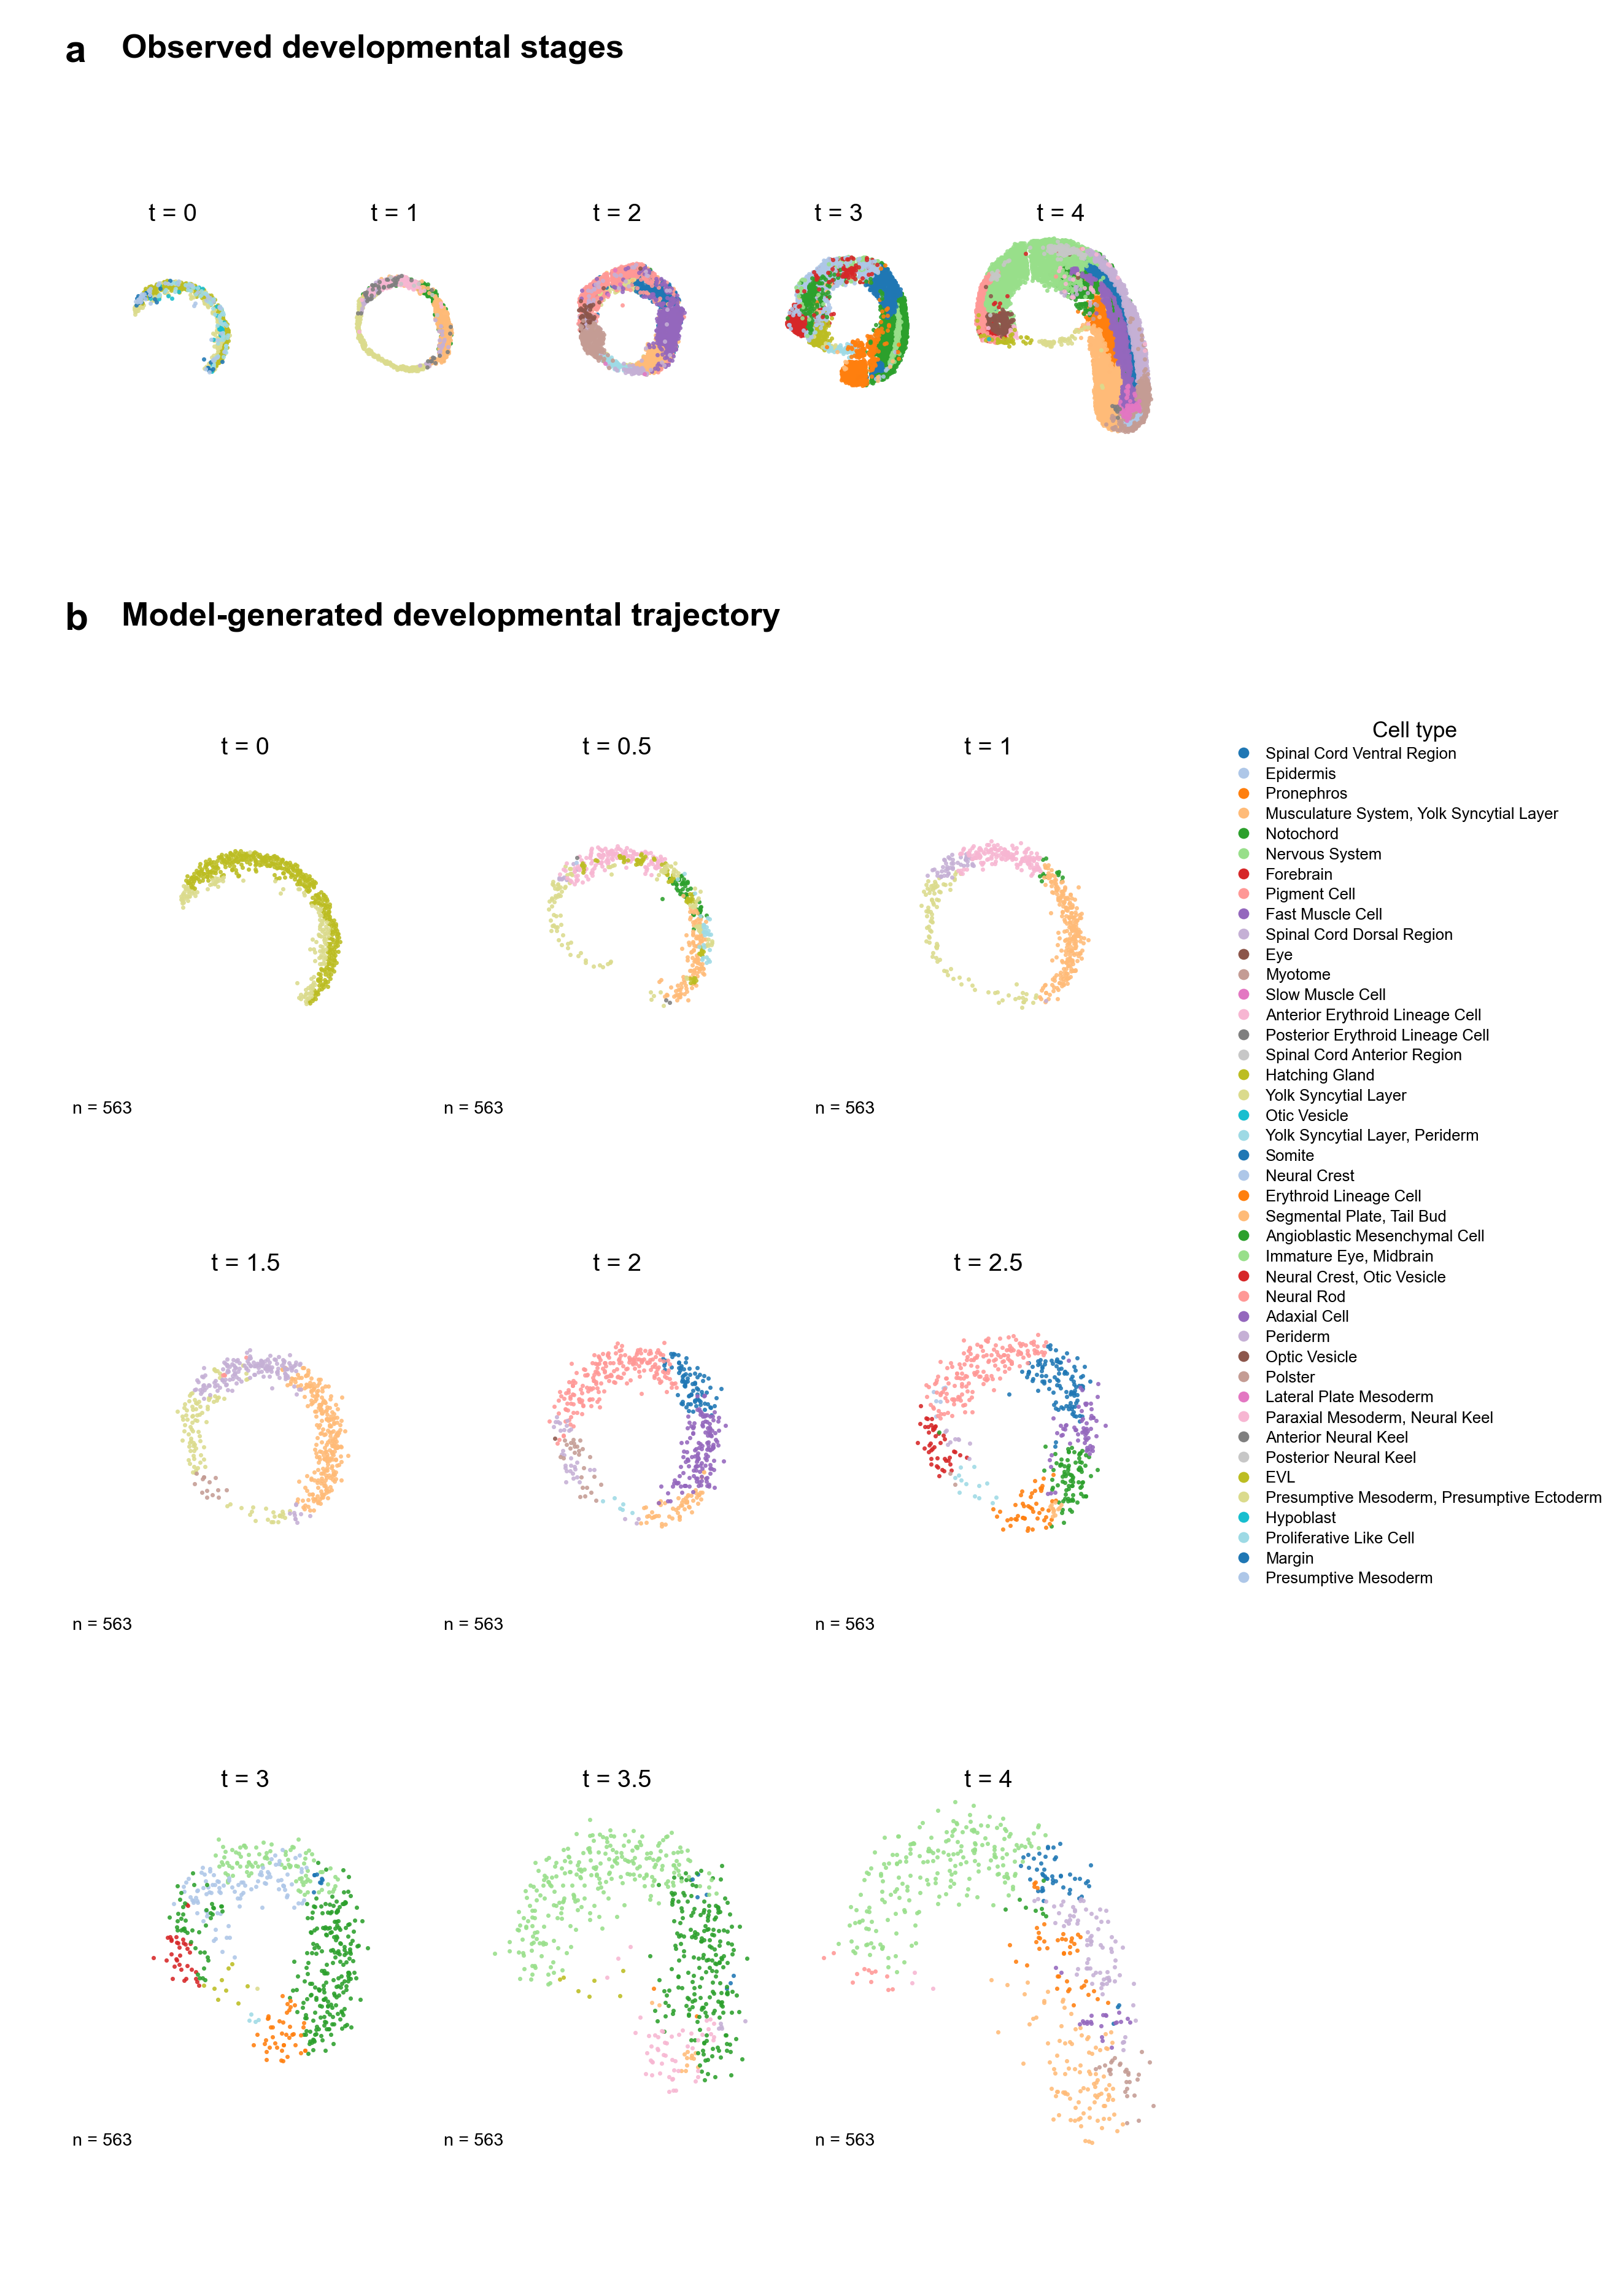

S32


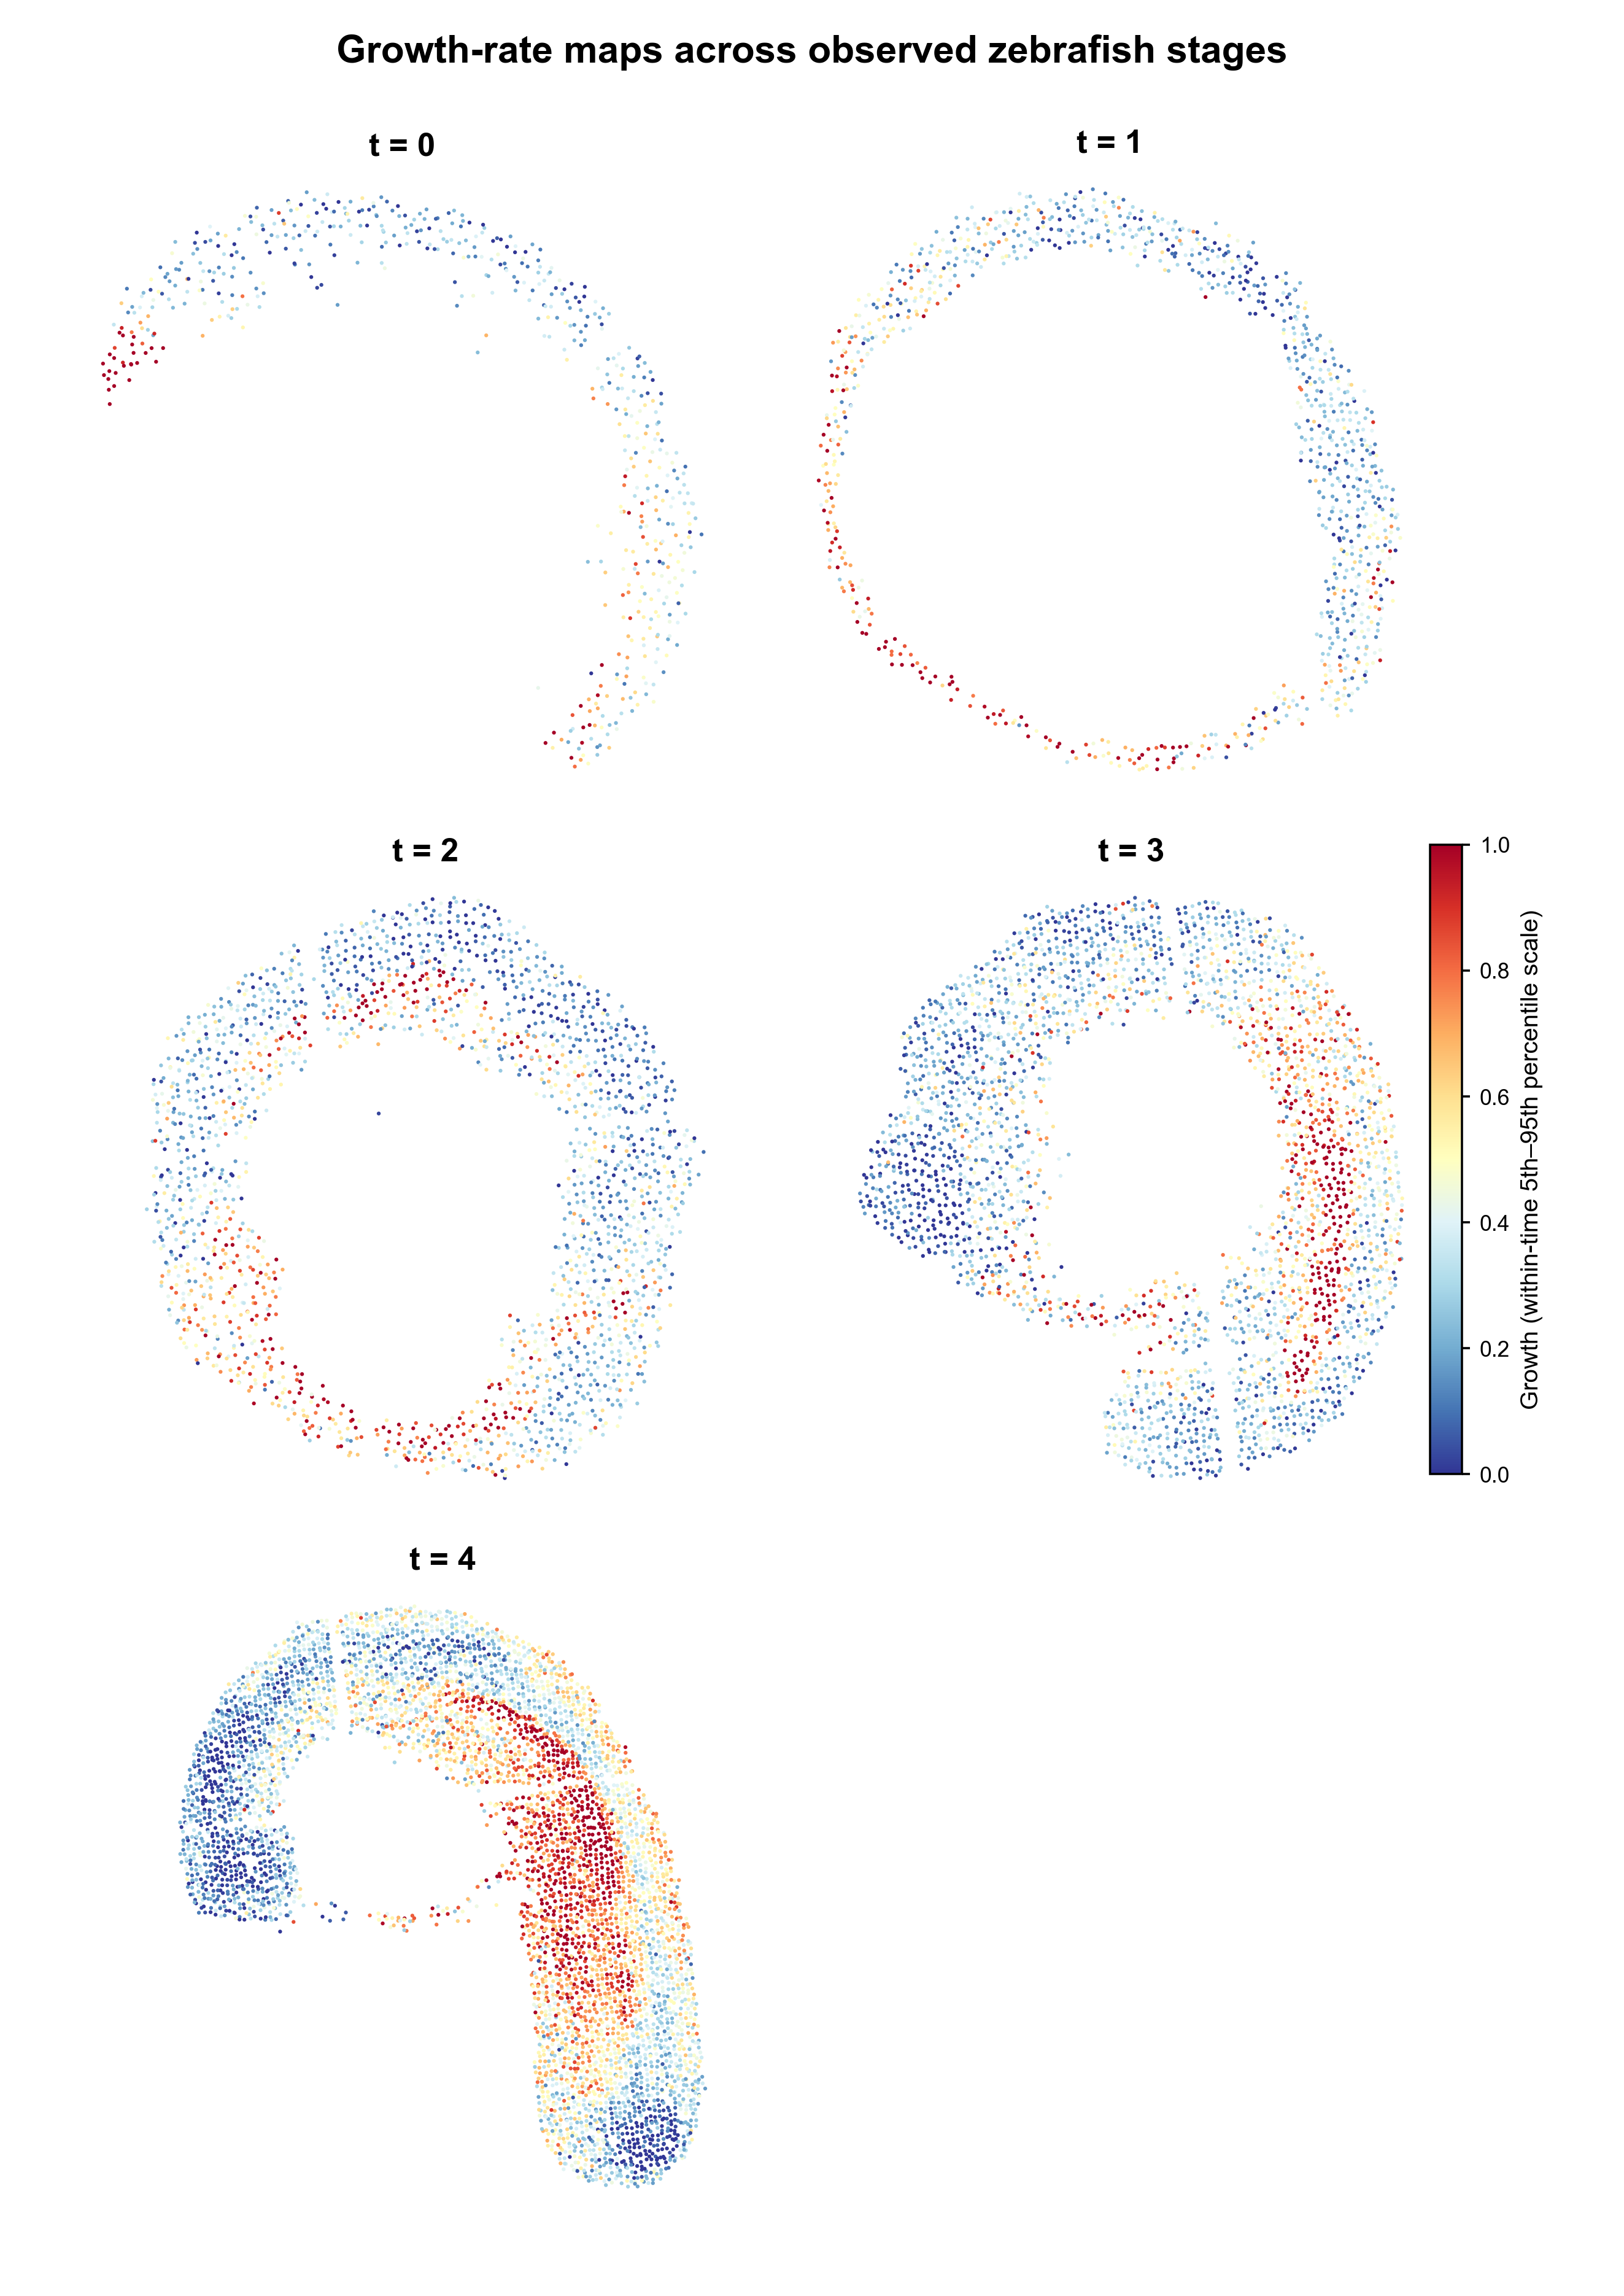

S33


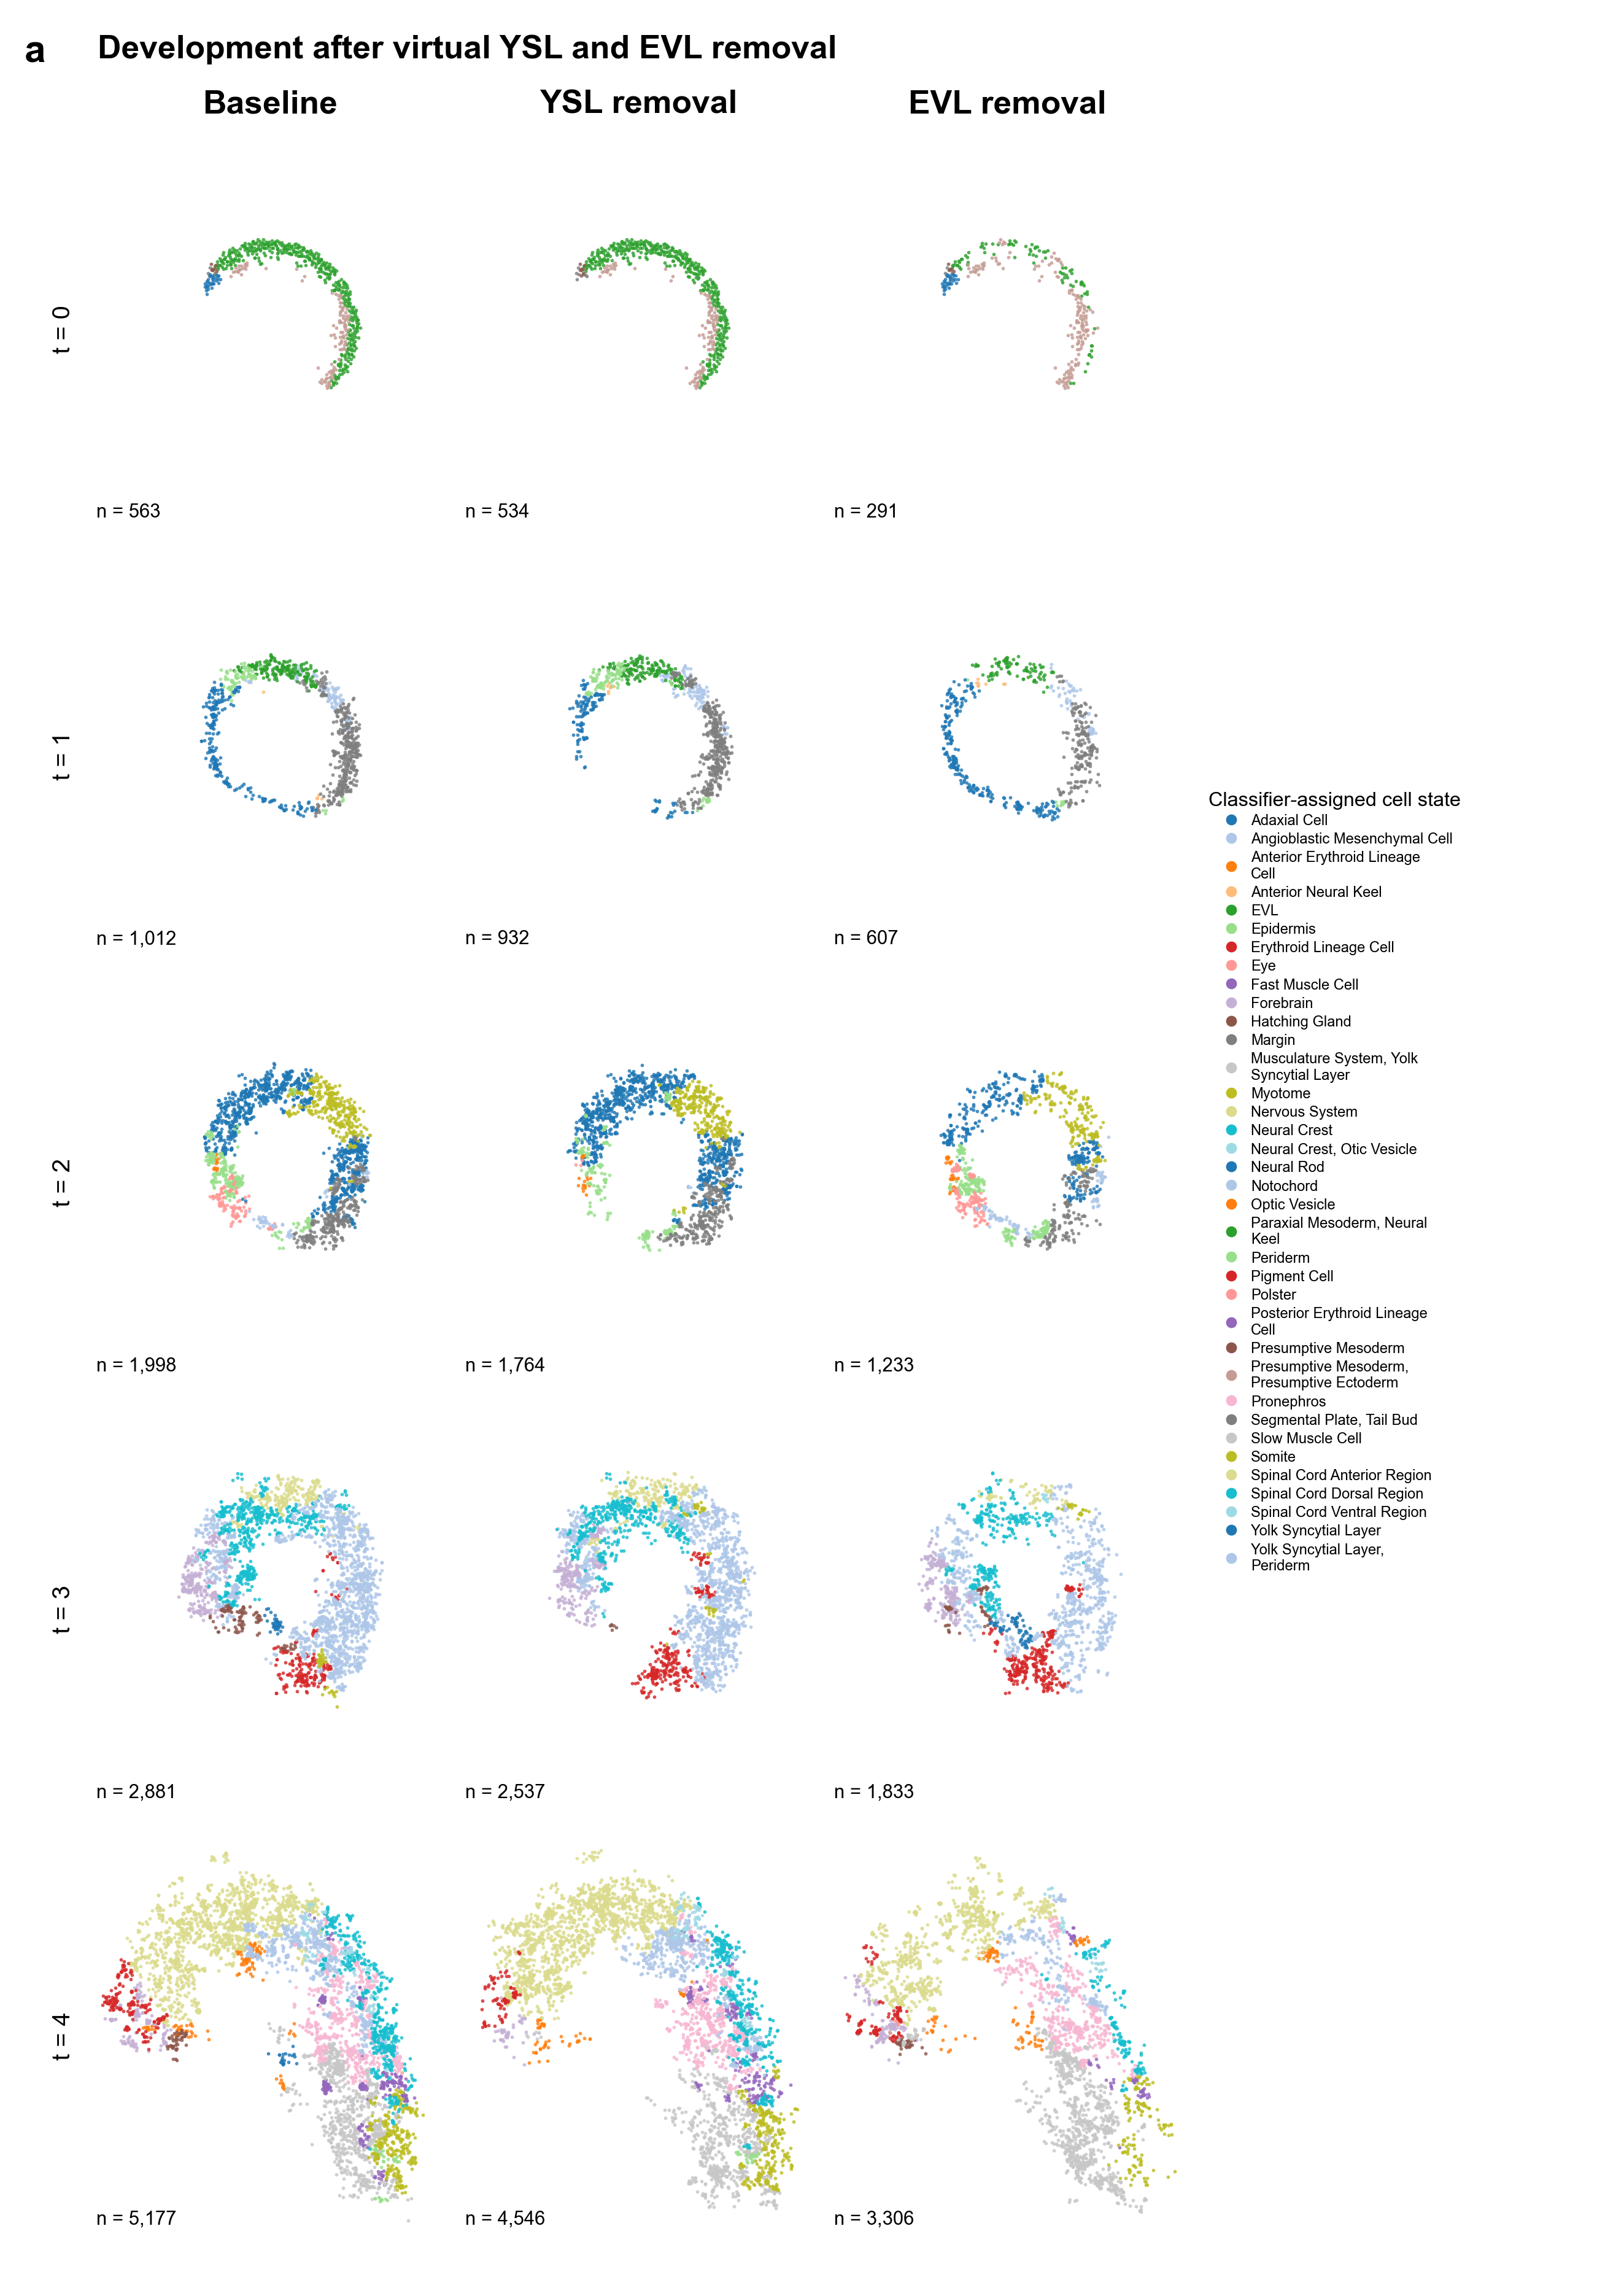

S34


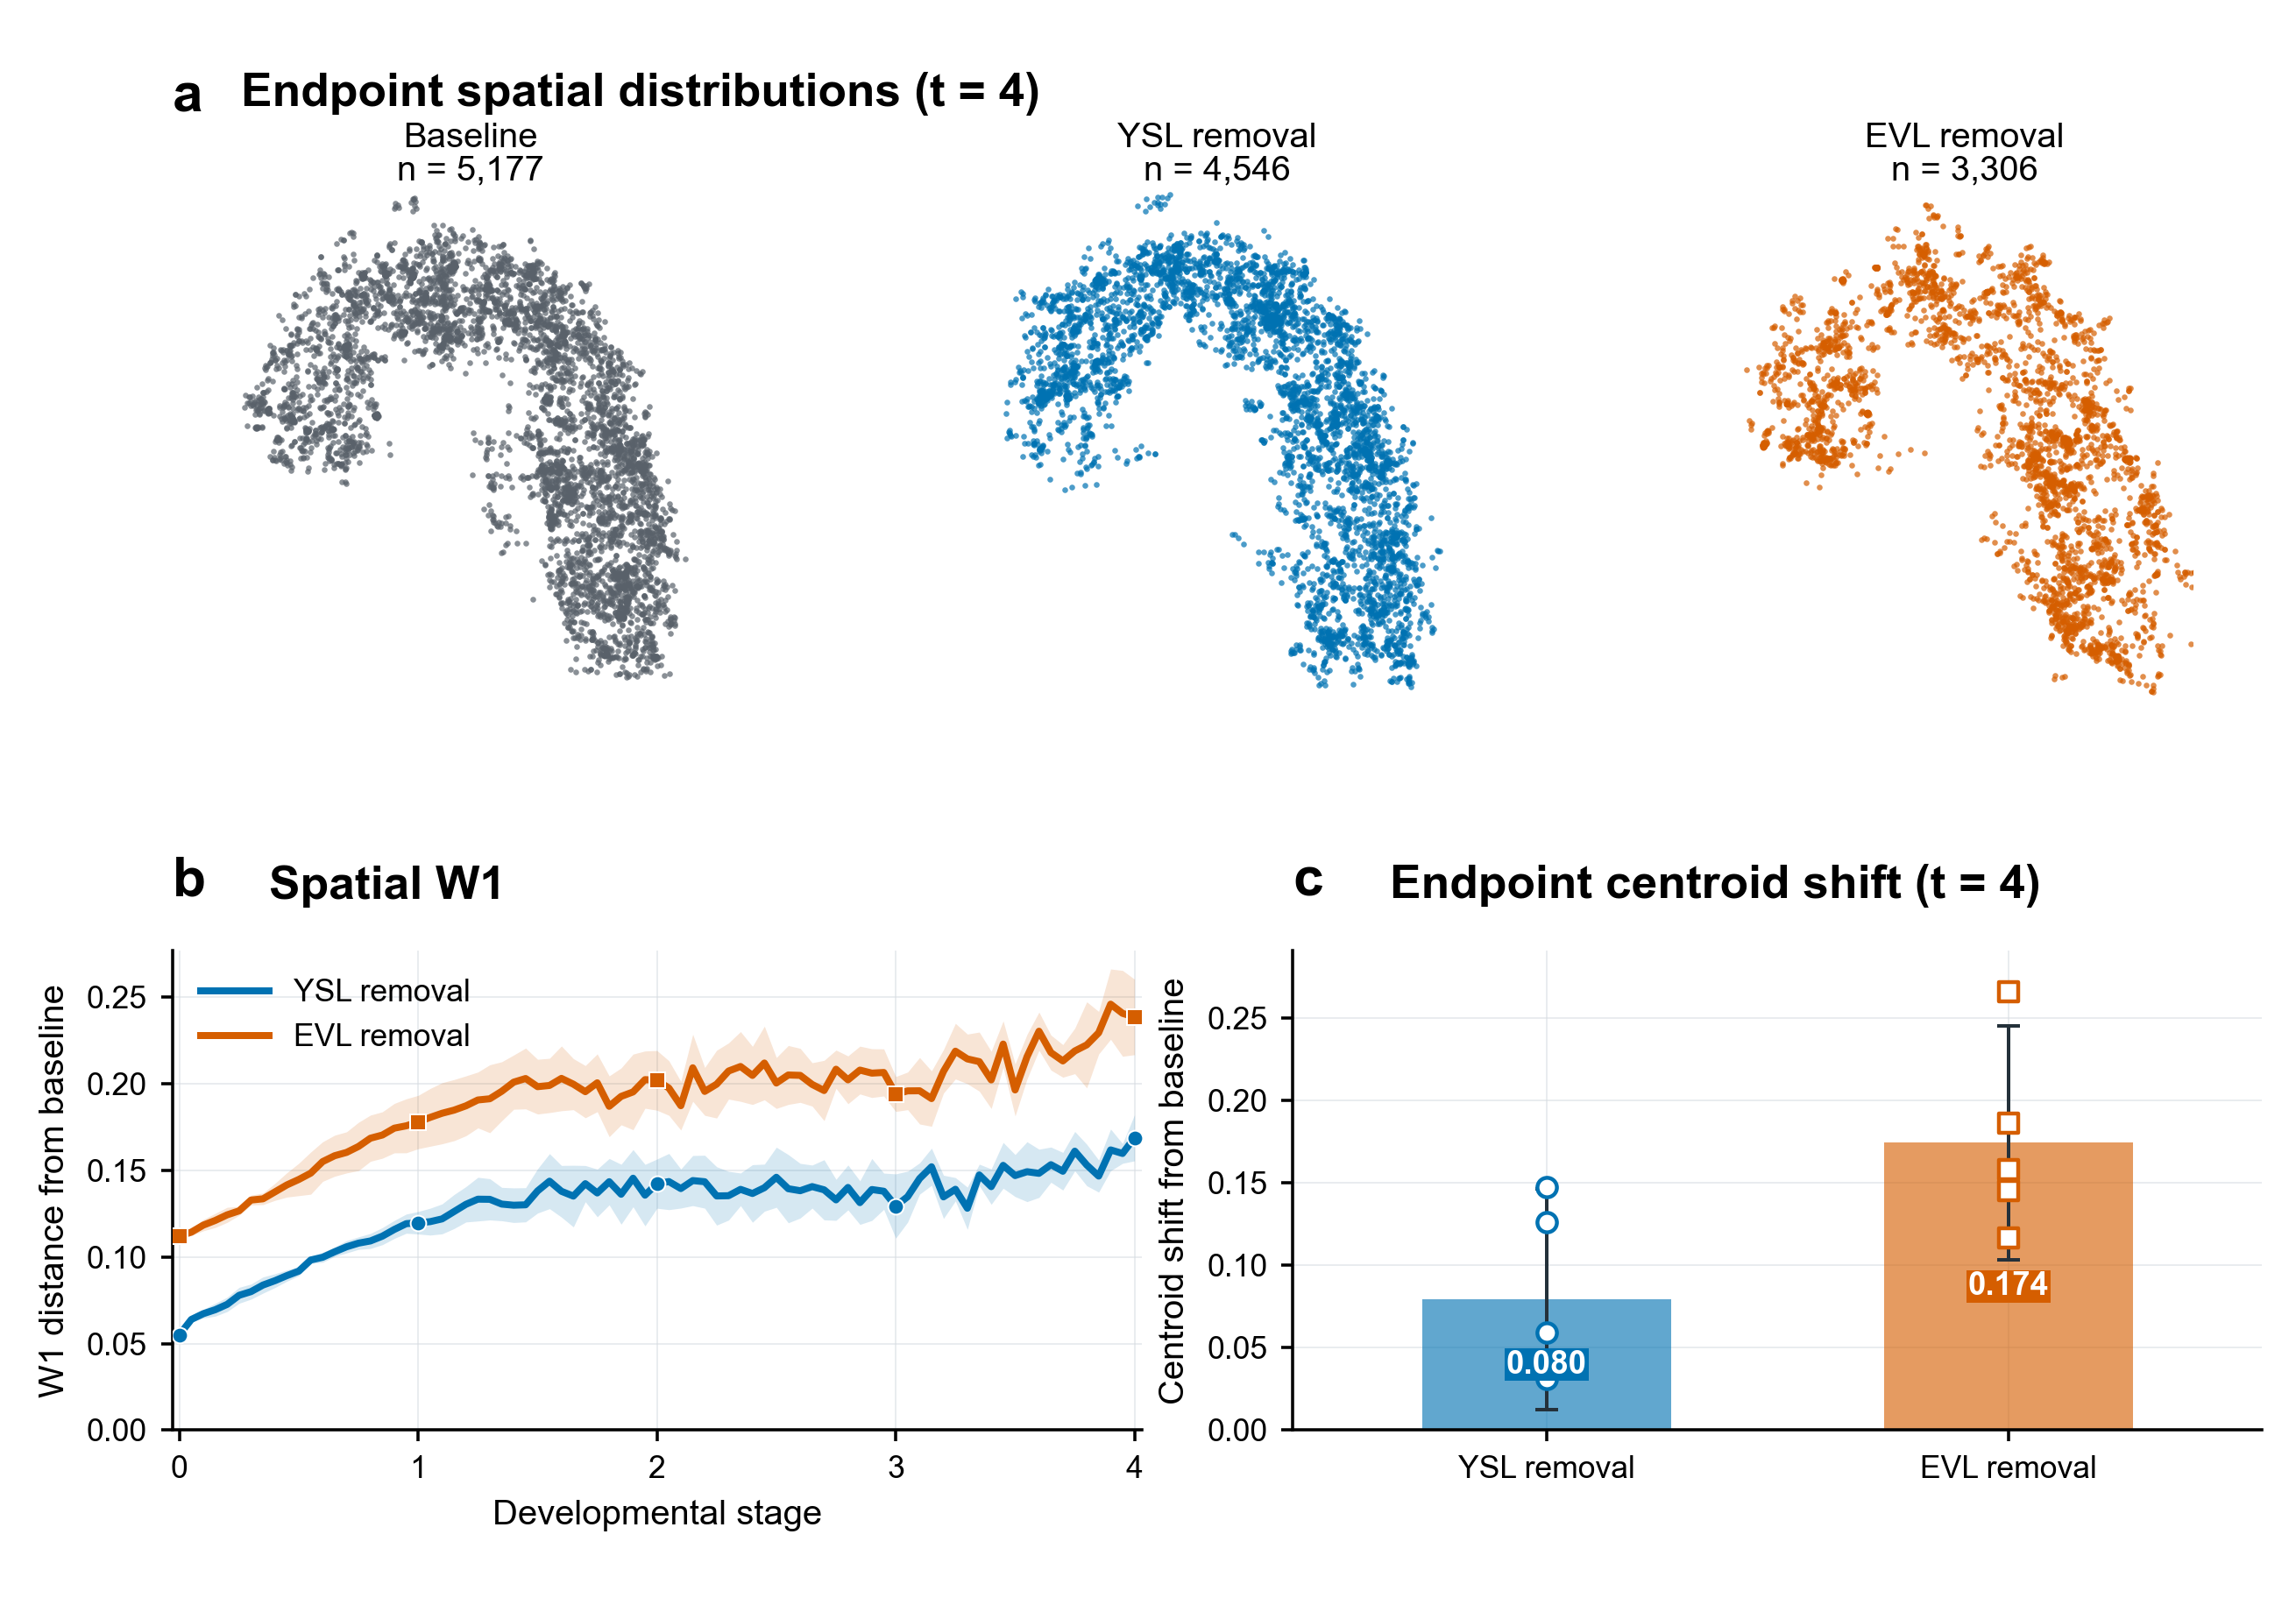

S35


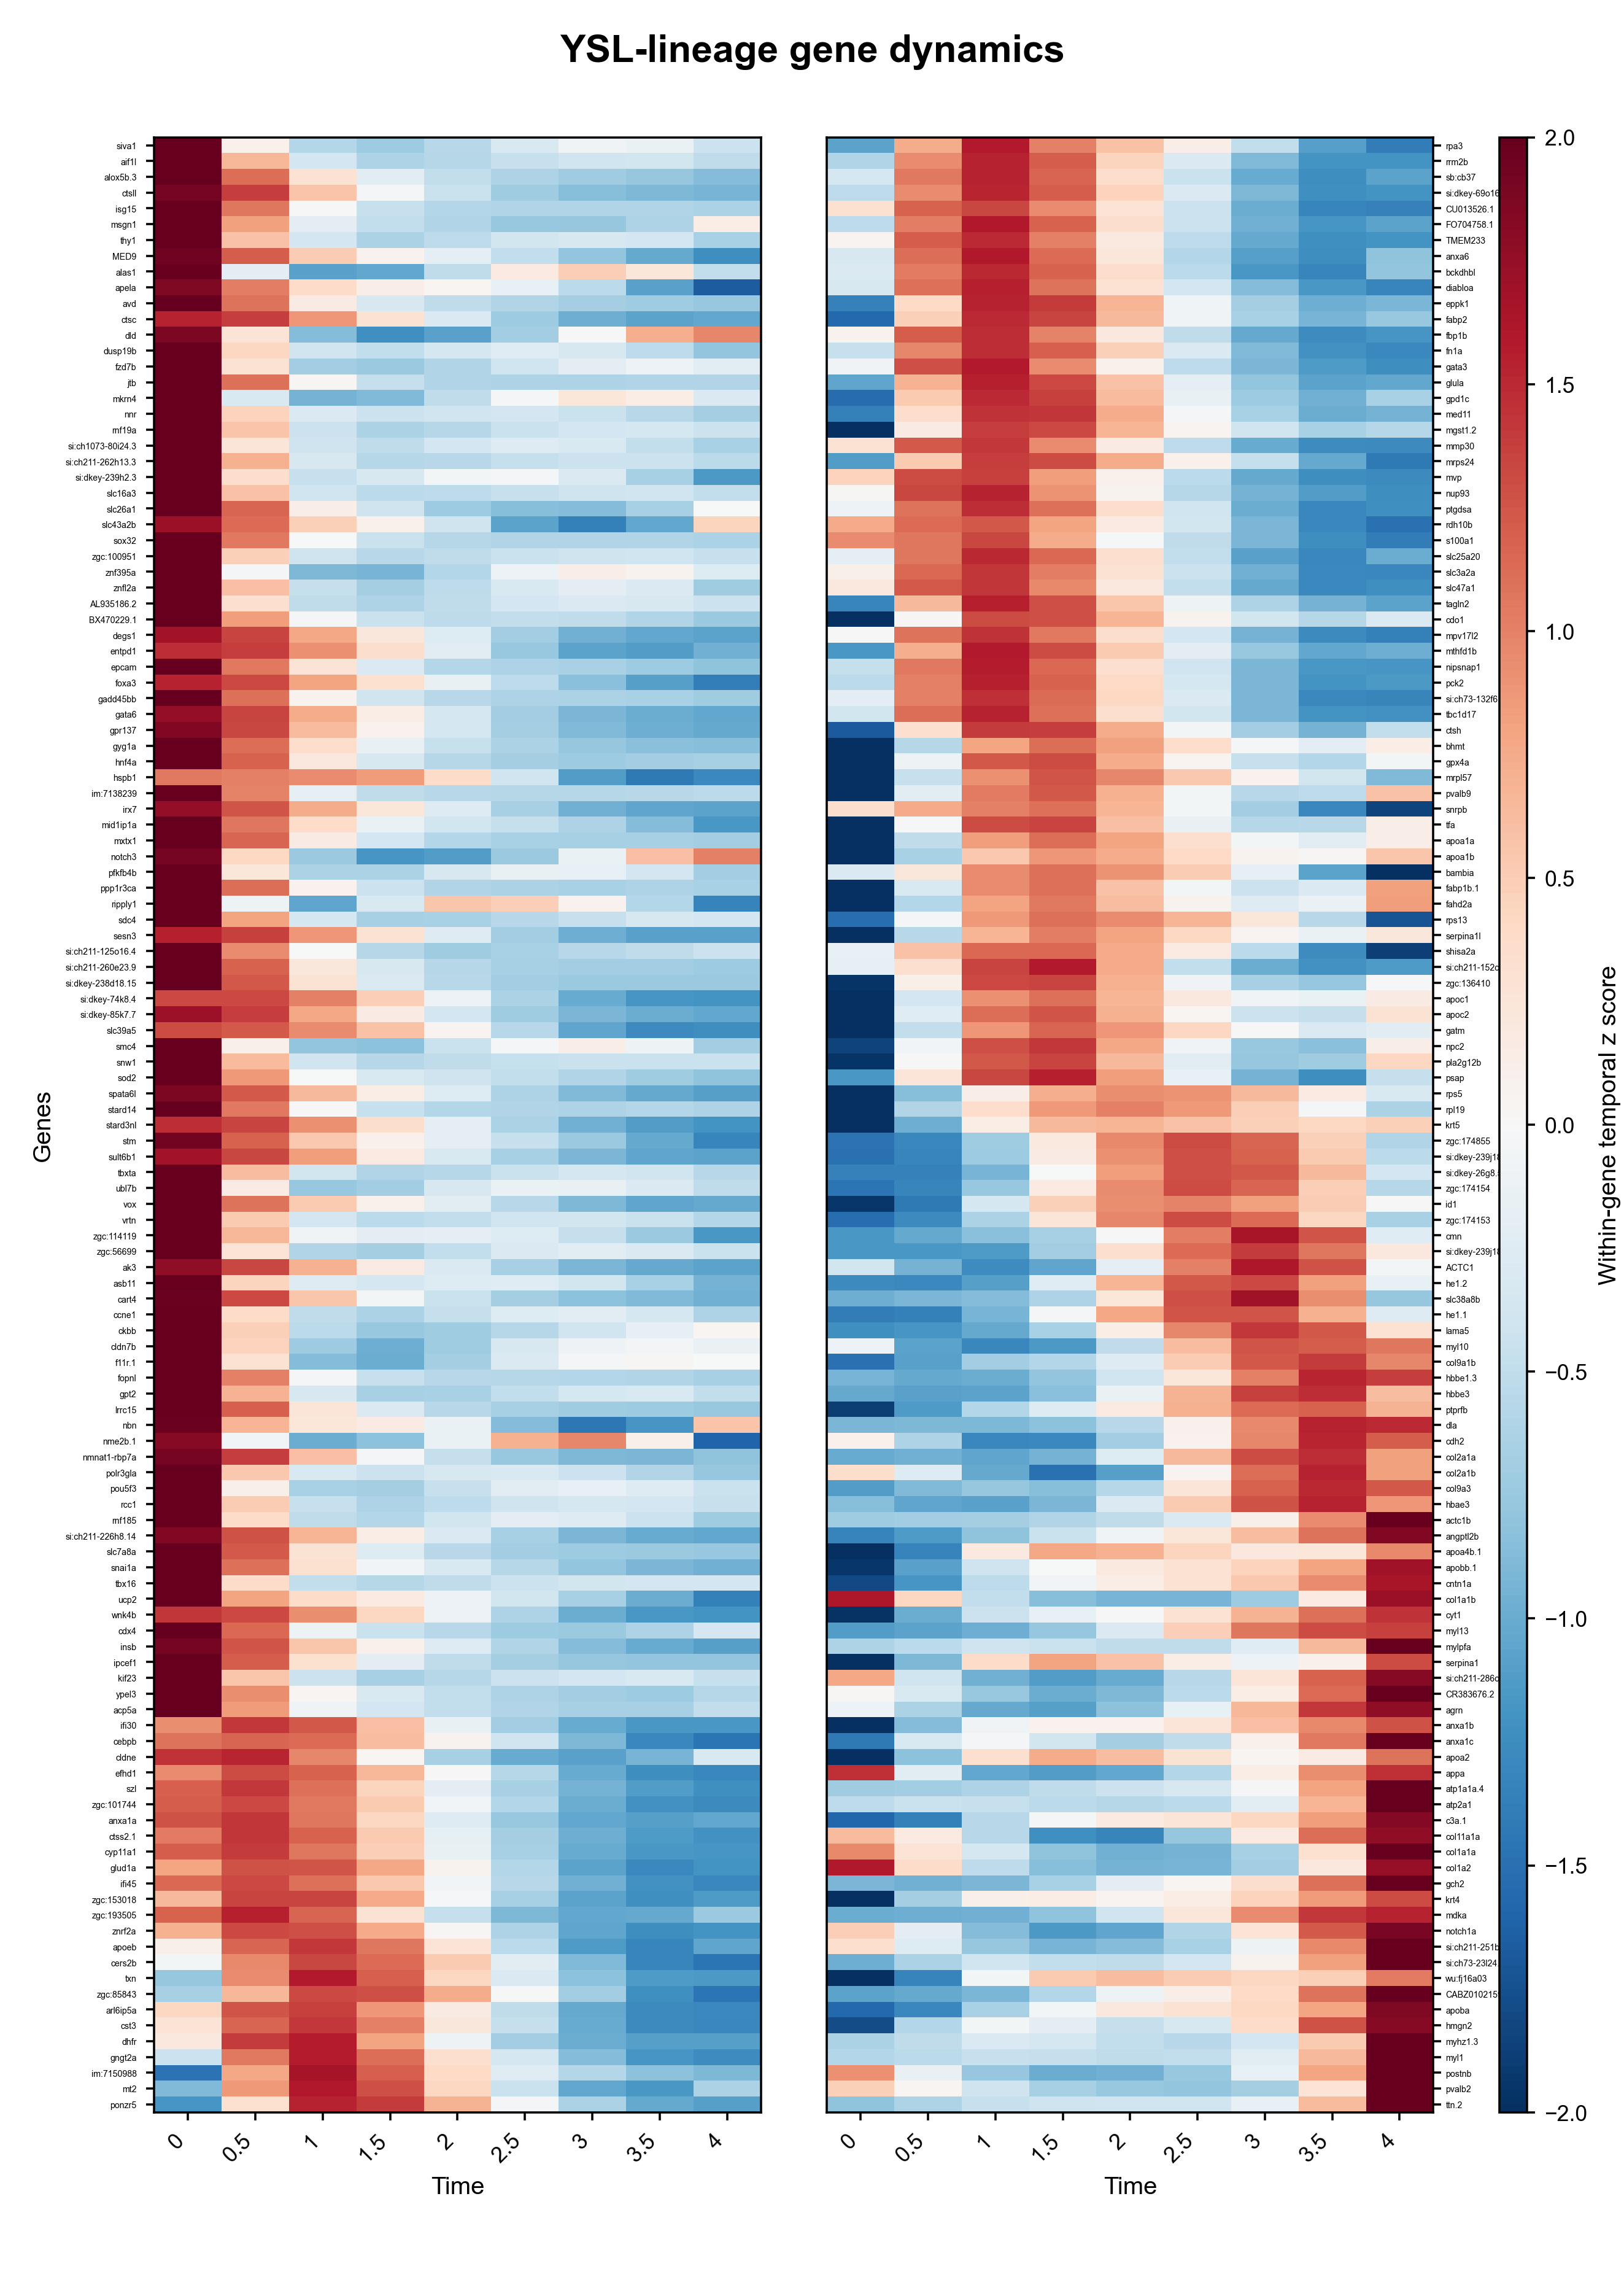

S36


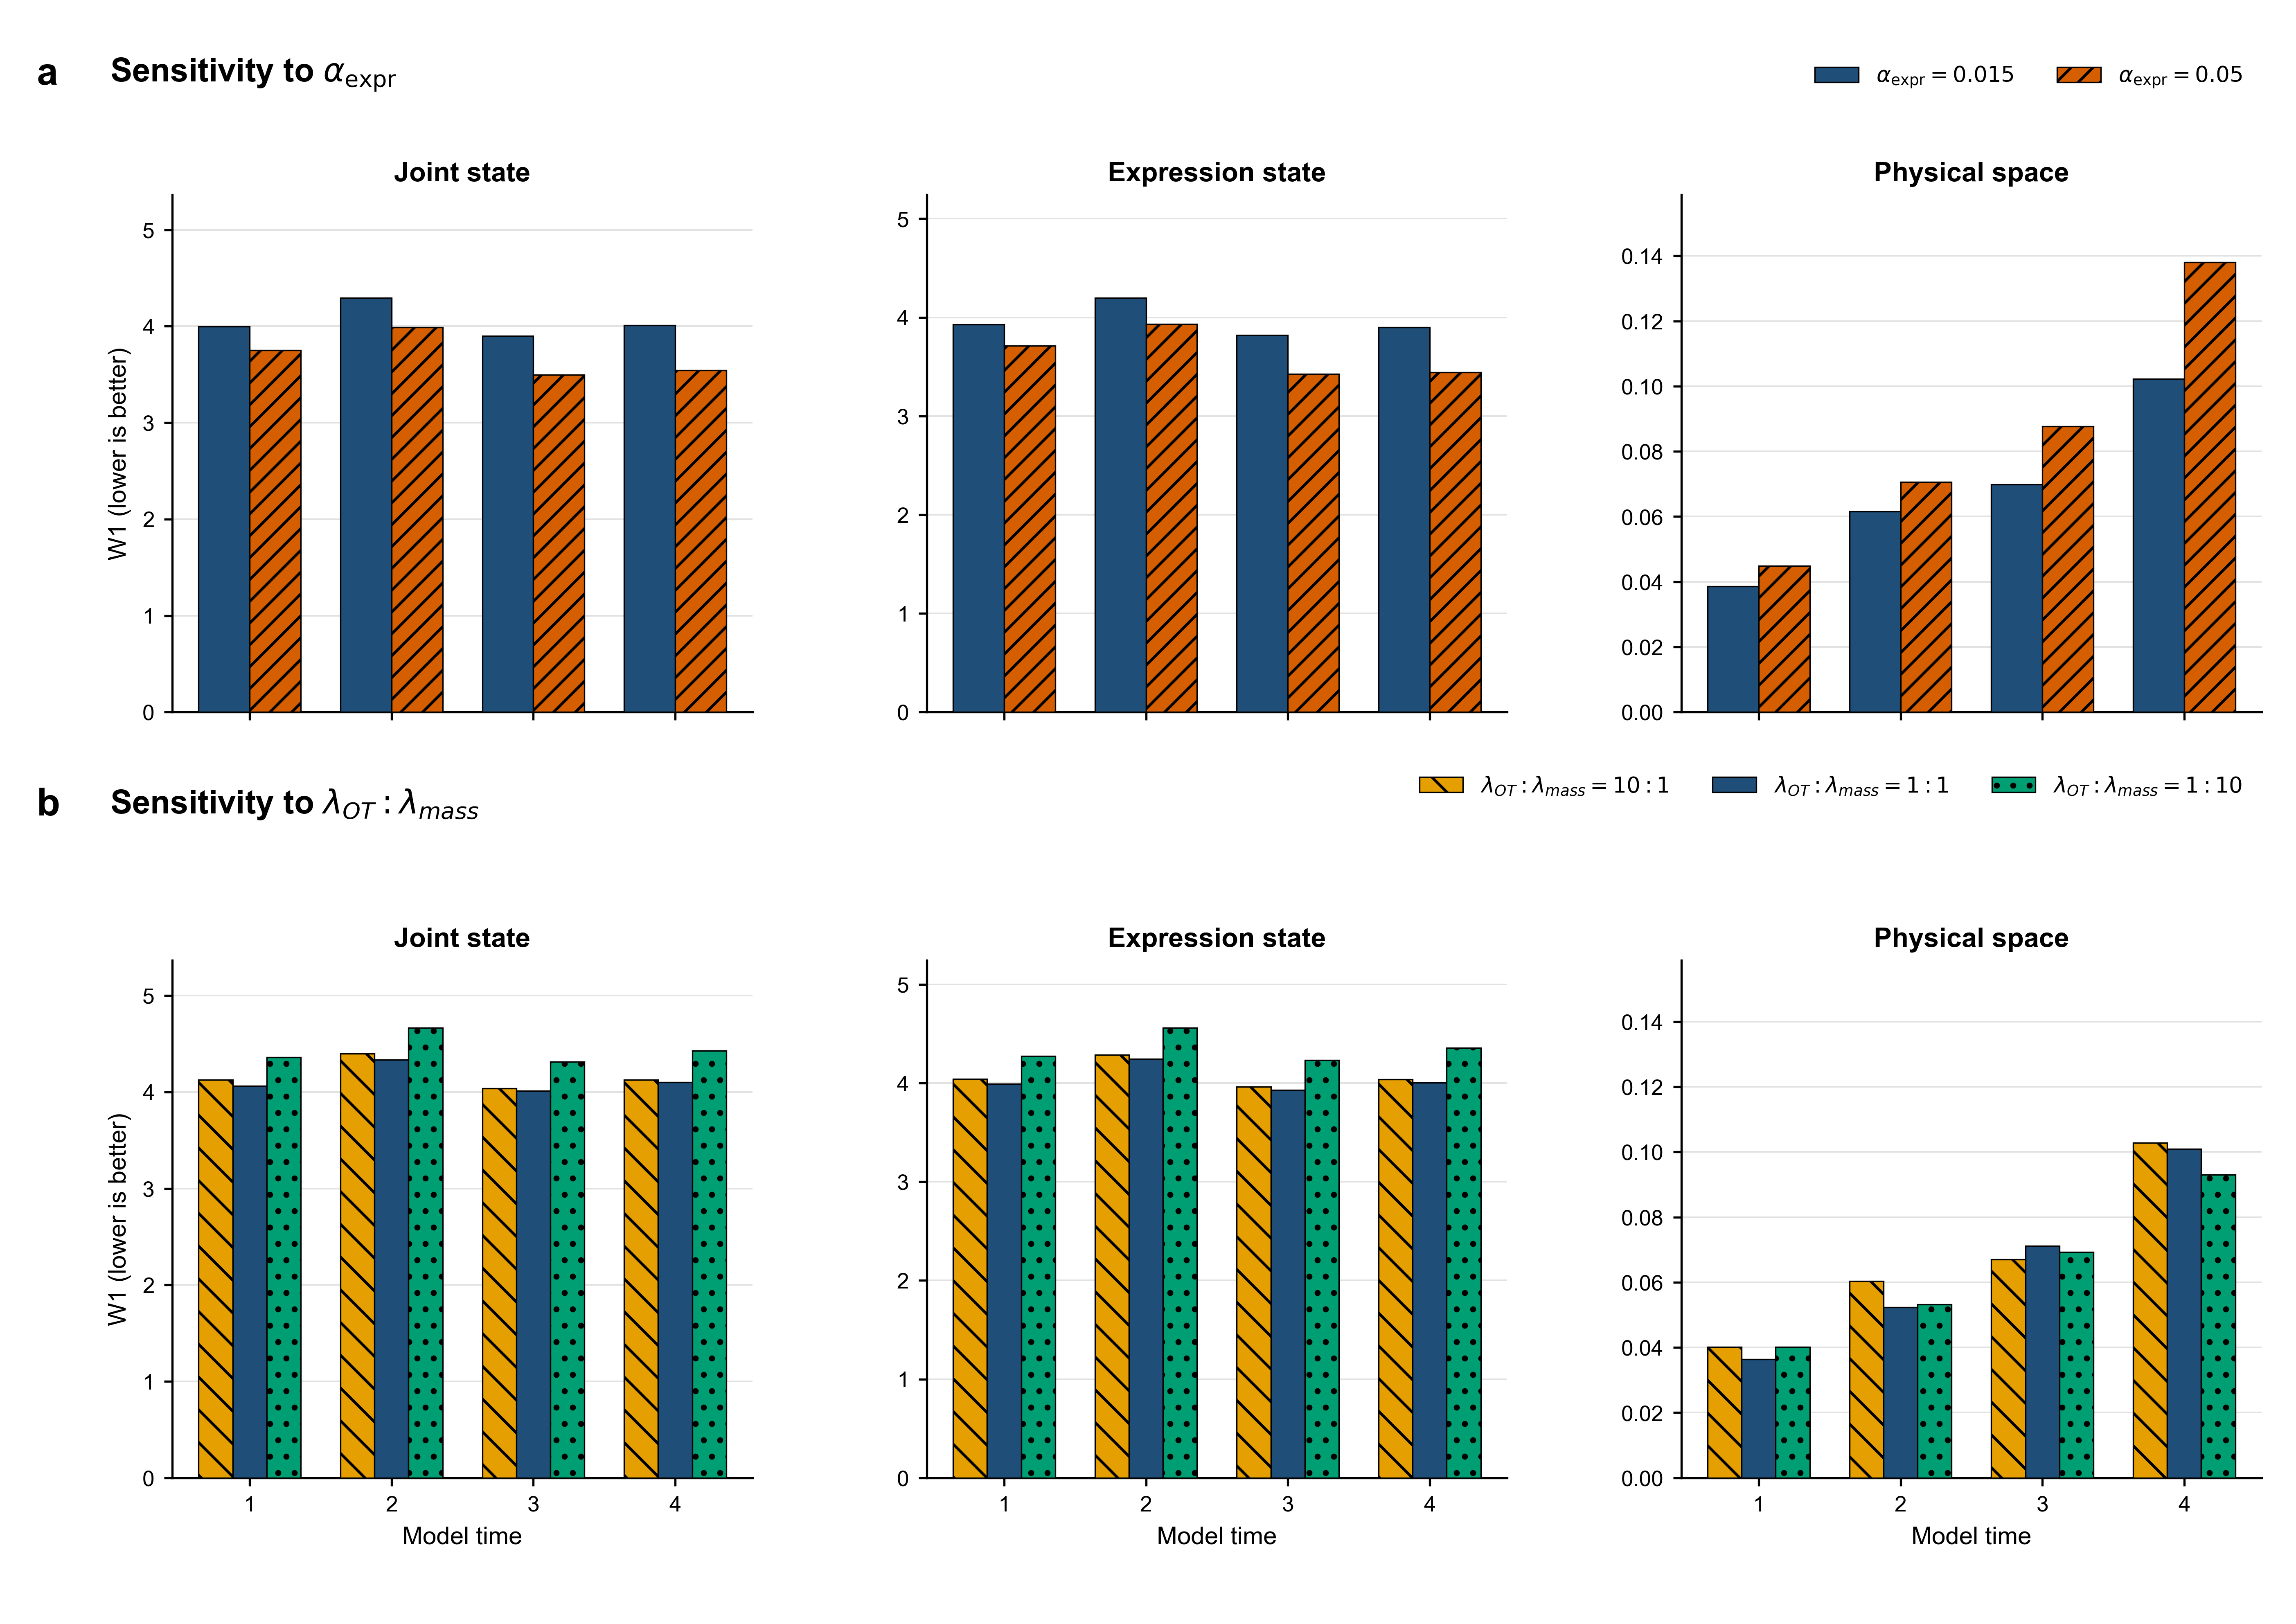

S37


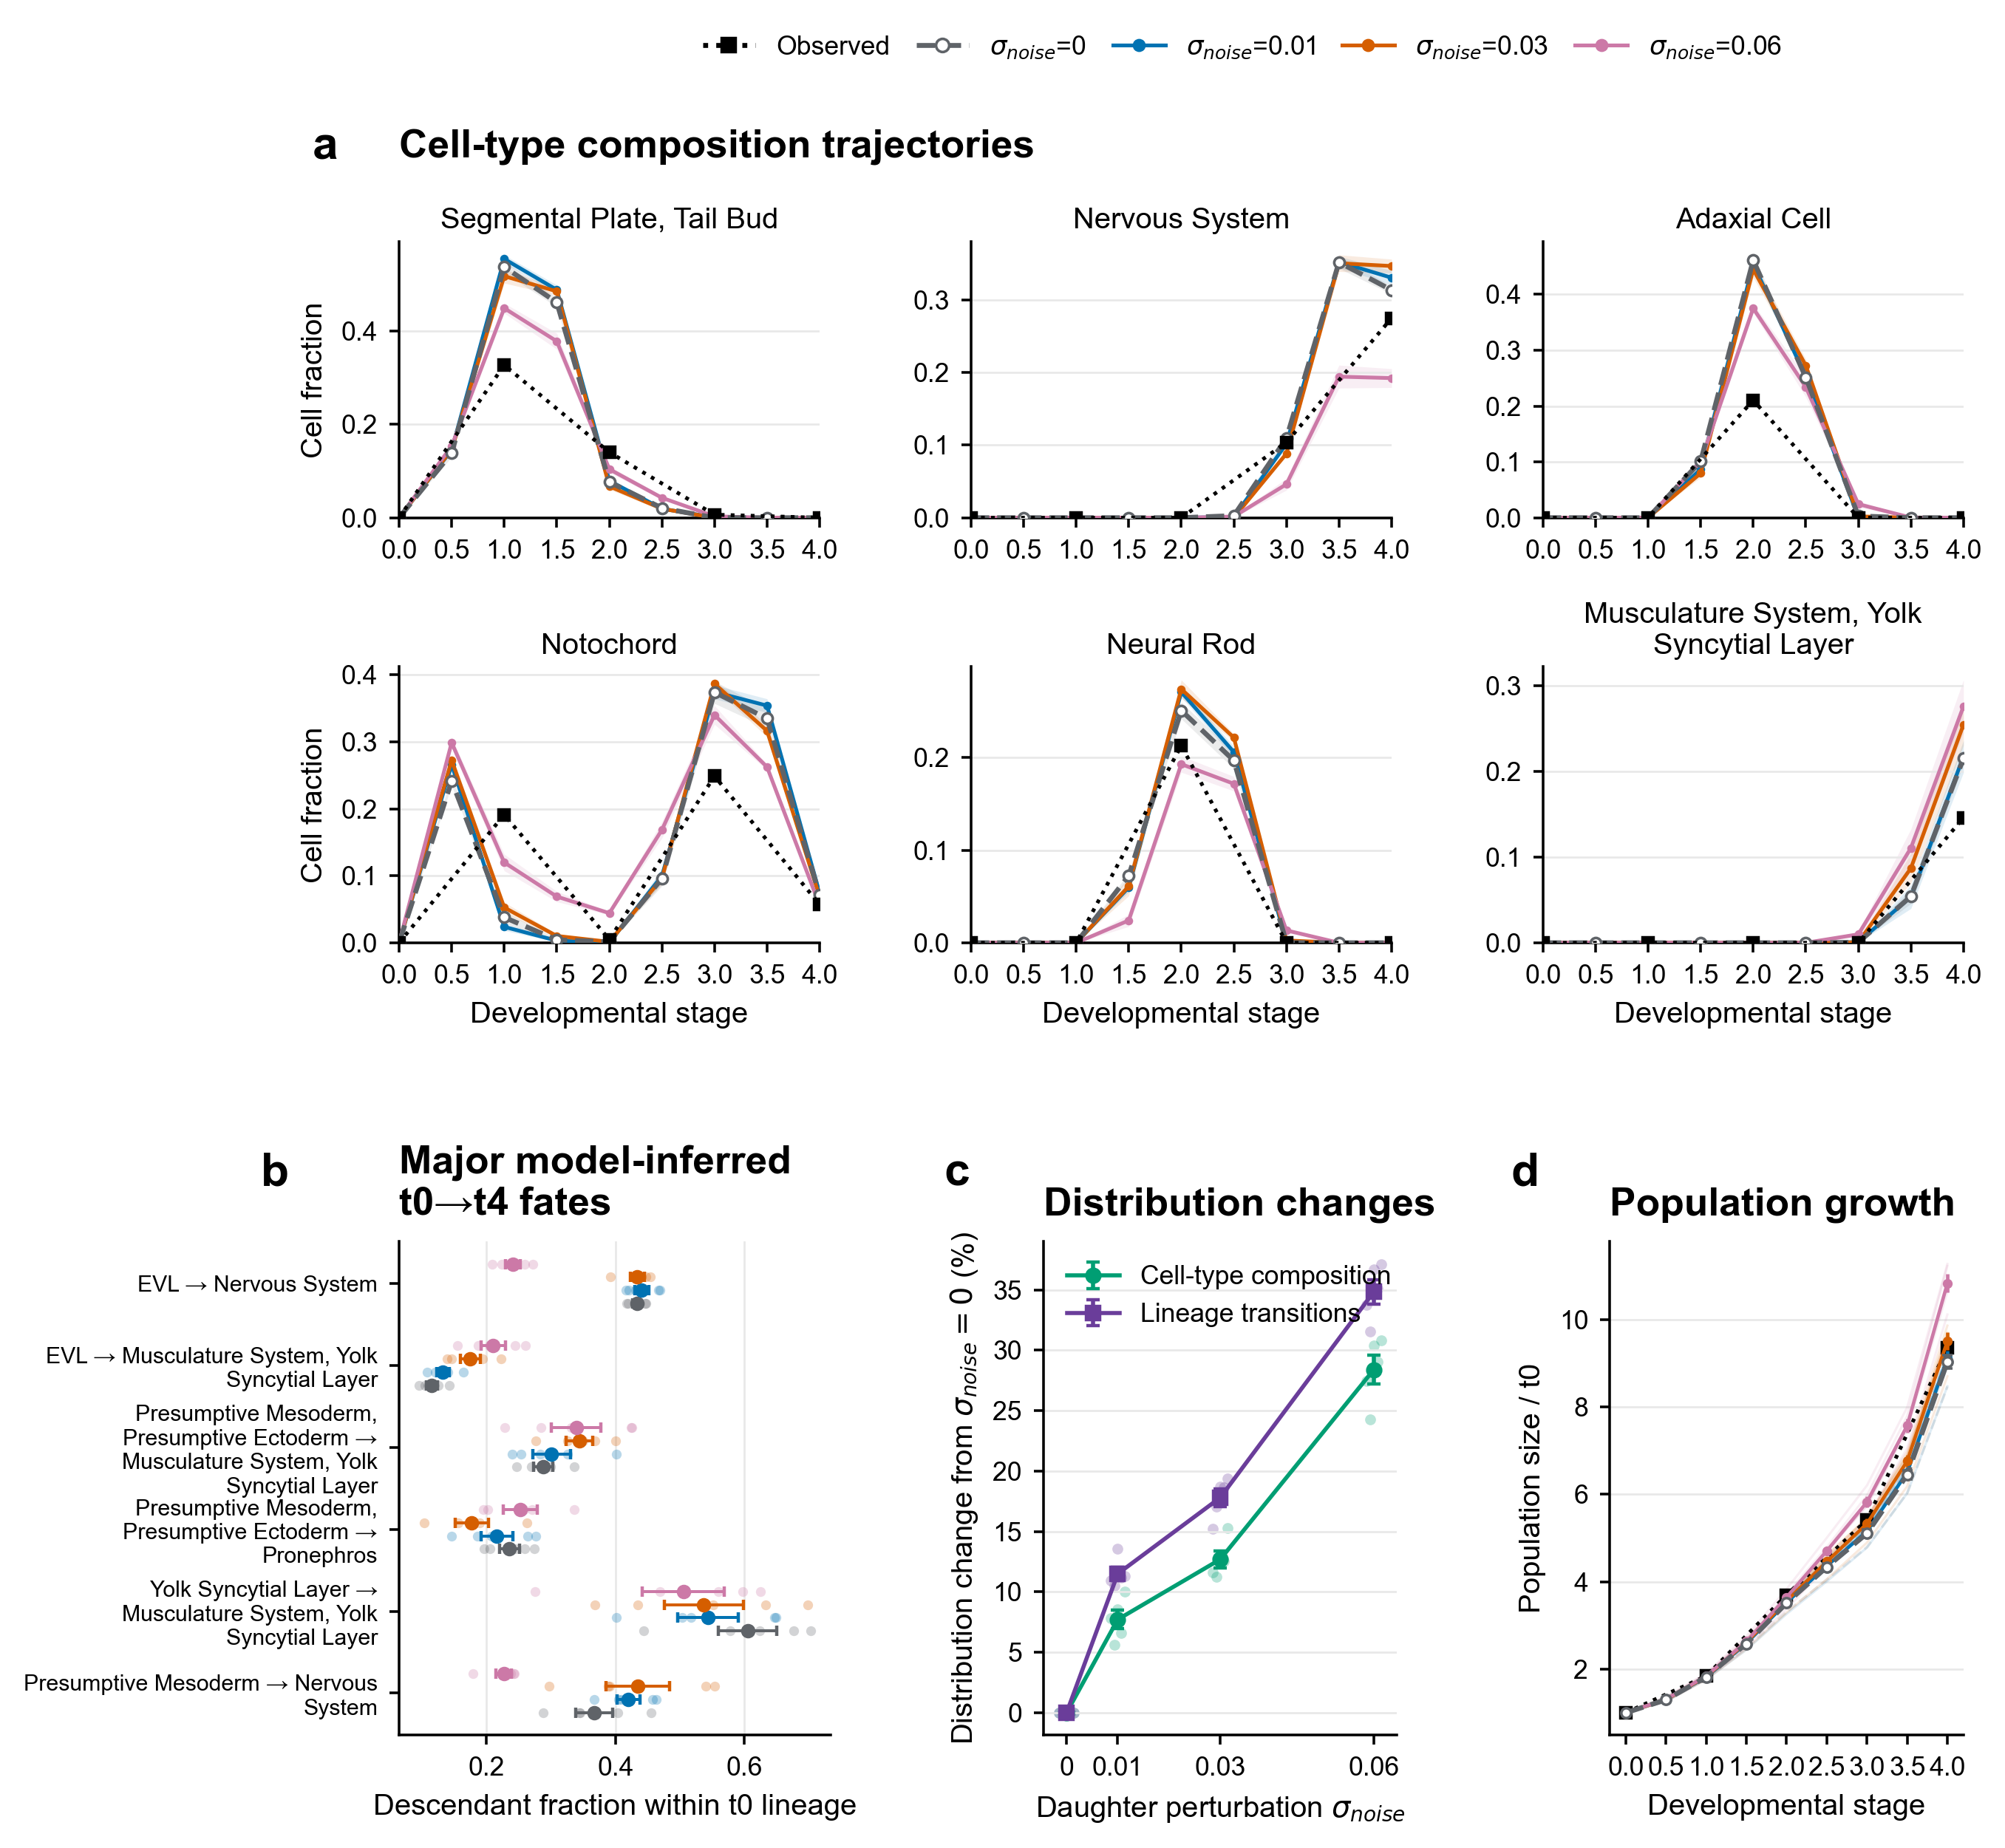

S38


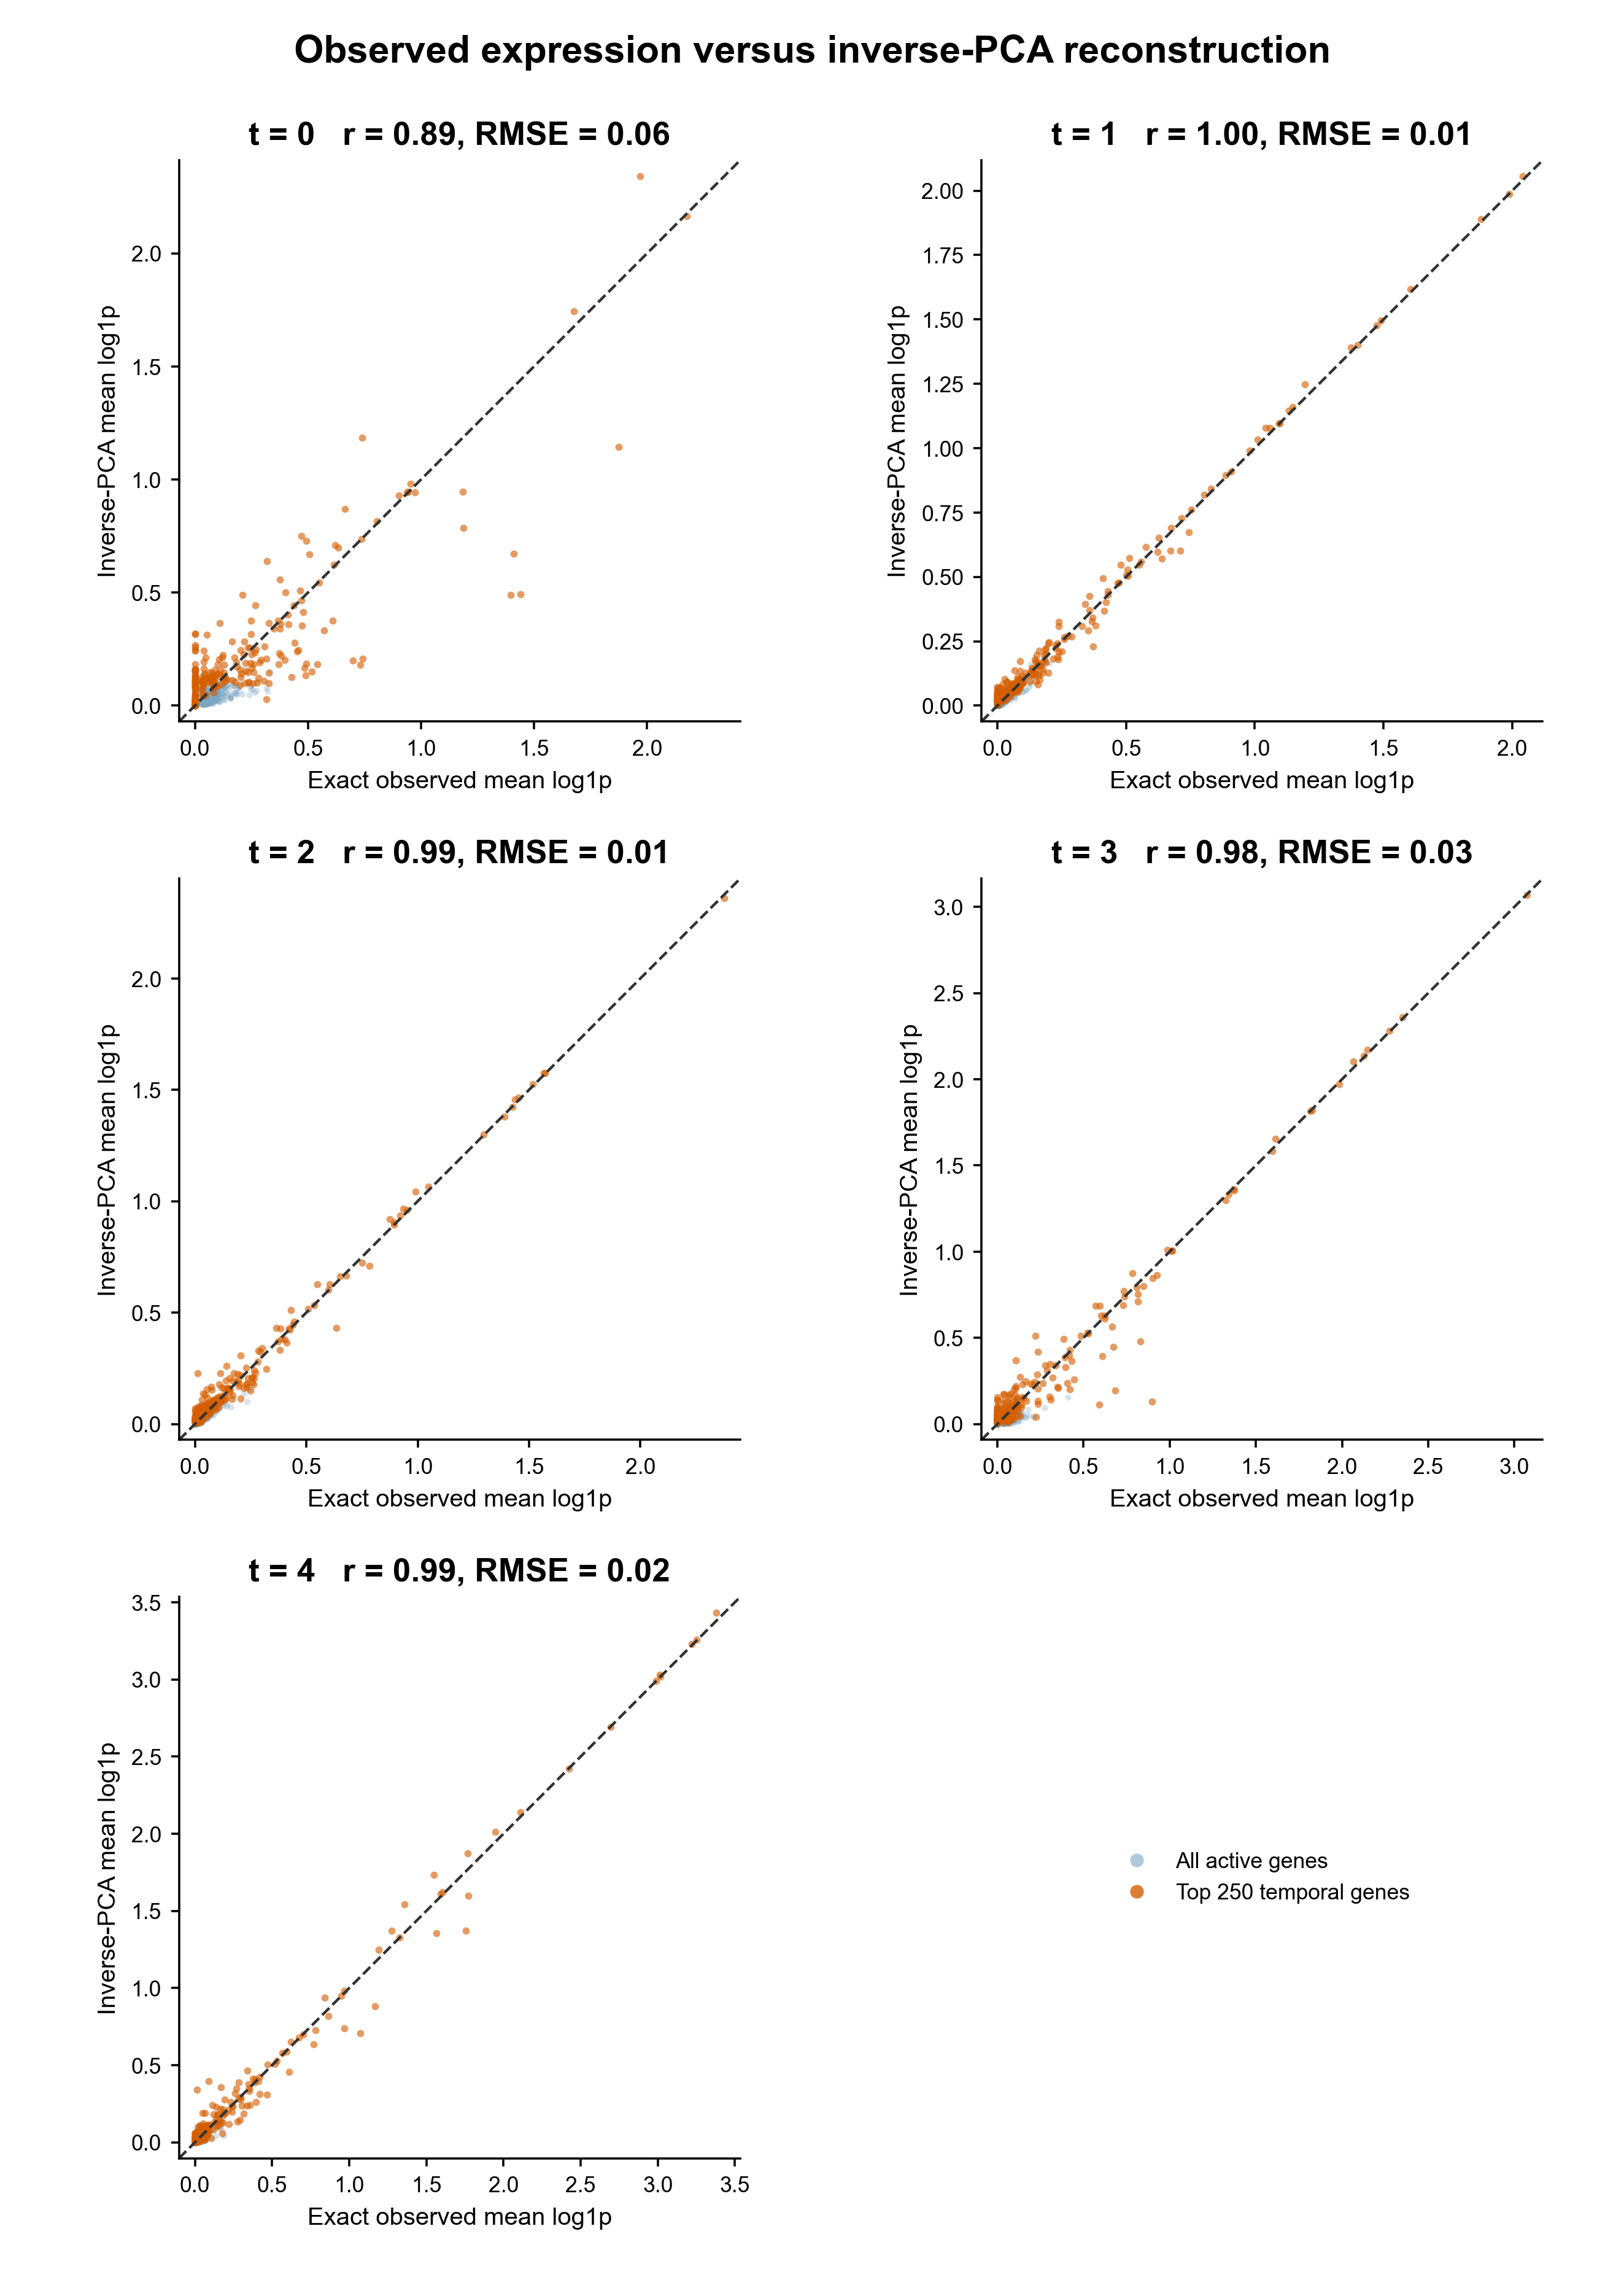

In [4]:
for figure_id, (_, png_path) in figures.items():
    print(figure_id.upper())
    display(Image(filename=str(png_path), width=720))